In [1]:
import colorsys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator, PercentFormatter


# ============================================================
# Publication-style defaults
# ============================================================
_PUB_COLORS = [
    "#2F6F4E",  # forest green
    "#C45C26",  # burnt orange
    "#2F5D8C",  # steel blue
    "#6B4C9A",  # muted violet
    "#B33A3A",  # soft crimson
    "#5A7A3A",  # olive
]
_PUB_LINESTYLES = ["-", "--", "-.", "-", "--", "-."]
_PUB_MARKERS = ["o", "s", "^", "D", "P", "X"]
_FIRST_CURVE_COLOR = "#2F6F4E"

_STYLE = {
    "fig_facecolor": "#FFFFFF",
    "ax_facecolor": "#FAFAF8",
    "spine": "#4A4A4A",
    "tick": "#3D3D3D",
    "label": "#2C2C2C",
    "title": "#1F1F1F",
    "grid": "#D0D0D0",
    "legend_edge": "#E2E2E2",
    "legend_face": "#FFFFFF",
}


def generate_vivid_colors(n):
    """Return n distinct vivid hex colors (deterministic)."""
    colors = []
    for i in range(int(n)):
        h = (i * 0.61803398875) % 1.0
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 0.85)
        colors.append(f"#{int(r * 255):02X}{int(g * 255):02X}{int(b * 255):02X}")
    return colors


def _assign_distinct_colors(n_dirs, color_list=None):
    """
    Fixed color order by dir_list index.
    Index 0 is always green; later indices follow _PUB_COLORS in order.
    """
    if n_dirs <= 0:
        return []

    # Stable palette: green first, then remaining fixed colors.
    palette = [_FIRST_CURVE_COLOR] + [c for c in _PUB_COLORS if c != _FIRST_CURVE_COLOR]

    # Extend deterministically if there are more curves than palette colors.
    if len(palette) < n_dirs:
        for c in generate_vivid_colors(max(n_dirs * 3, 8)):
            if c not in palette:
                palette.append(c)
            if len(palette) >= n_dirs:
                break

    colors = palette[:n_dirs]

    # Optional per-curve overrides; index 0 stays green.
    if color_list is not None:
        for i in range(1, min(n_dirs, len(color_list))):
            if color_list[i] is not None:
                colors[i] = color_list[i]

    return colors


def _parse_result_json(data):
    """Return n array, mean EER, and optional per-n user EER lists."""
    if isinstance(data, dict) and ("n" in data and "avg_eer" in data):
        n = np.array(data["n"], dtype=int)
        avg_eer = np.array(data["avg_eer"], dtype=float)
        return n, avg_eer, None

    bucket = {}
    for user_block in data.values() if isinstance(data, dict) else []:
        if not isinstance(user_block, dict):
            continue
        for rec in user_block.values():
            if not isinstance(rec, dict):
                continue
            n_val = rec.get("n")
            eer_val = rec.get("EER", rec.get("avg_eer"))
            if n_val is None or eer_val is None:
                continue
            bucket.setdefault(int(n_val), []).append(float(eer_val))

    if not bucket:
        raise ValueError("Unsupported JSON structure for plotting")

    sorted_n = sorted(bucket.keys())
    n = np.array(sorted_n, dtype=int)
    avg_eer = np.array([np.mean(bucket[k]) for k in sorted_n])
    return n, avg_eer, bucket


def _nearest_n_for_event(target_event, n_values, seq_length, shift):
    events = n_values * seq_length + shift
    idx = int(np.argmin(np.abs(events - target_event)))
    return int(n_values[idx])


def _drop_max_eer_outlier(values):
    """Remove one maximum EER value (for box-plot outlier trimming)."""
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return values
    return np.delete(values, int(np.argmax(values)))


def _draw_box_at(ax, x, values, color, offset=0, box_width=22, alpha=0.22):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return None, None

    q1, med, q3 = np.percentile(values, [25, 50, 75])
    vmin, vmax = values.min(), values.max()
    cx = x + offset
    half = box_width / 2

    rect = Rectangle(
        (cx - half, q1),
        box_width,
        q3 - q1,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=1.35,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.plot([cx - half, cx + half], [med, med], color=color, linewidth=1.8, solid_capstyle="round", zorder=4)
    ax.plot([cx, cx], [vmin, q1], color=color, linewidth=1.15, solid_capstyle="round", zorder=4, alpha=0.9)
    ax.plot([cx, cx], [q3, vmax], color=color, linewidth=1.15, solid_capstyle="round", zorder=4, alpha=0.9)

    cap = box_width * 0.28
    ax.plot([cx - cap, cx + cap], [vmin, vmin], color=color, linewidth=1.15, solid_capstyle="round", zorder=4, alpha=0.9)
    ax.plot([cx - cap, cx + cap], [vmax, vmax], color=color, linewidth=1.15, solid_capstyle="round", zorder=4, alpha=0.9)

    return float(np.mean(values)), float(np.std(values))


def _style_publication_axes(ax, fig):
    """Visual-only axis polish; does not change data/logic."""
    fig.patch.set_facecolor(_STYLE["fig_facecolor"])
    ax.set_facecolor(_STYLE["ax_facecolor"])

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(_STYLE["spine"])
        ax.spines[side].set_linewidth(1.15)

    ax.tick_params(
        axis="both",
        which="major",
        colors=_STYLE["tick"],
        labelsize=10,
        length=4.5,
        width=1.0,
        direction="out",
    )
    ax.grid(
        which="major",
        axis="both",
        linestyle=(0, (3, 3)),
        color=_STYLE["grid"],
        alpha=0.55,
        linewidth=0.85,
        zorder=0,
    )
    ax.set_axisbelow(True)


# ============================================================
# Publication-style EER comparison plot
# ============================================================
def plot_eer_publication_style(
    dir_list,
    max_event=650,
    seq_length=120,
    title=None,
    legend_names=None,
    shift_list=None,
    per_user_dir_list=None,
    box_event_positions=(300, 450, 600),
    linestyle_list=None,
    marker_list=None,
    color_list=None,
    show_boxplots=True,
    show_errorbars=True,
    drop_max_eer_outlier=False,
    panel_label=None,
    dataset_name="Balabit",
    figsize=(7.8, 5.2),
    plot_n_set={1, 5, 10, 15},
    x_axis_start_event=0,
):
    """
    Publication-style Mean EER vs Number of Events plot.

    Supports dense mean curves, per-user box plots, and error bars
    at selected event positions (similar to paper figures).

    If drop_max_eer_outlier is True, each box plot drops its largest
    per-user EER before drawing (and before error-bar statistics).

    x_axis_start_event controls x-axis left bound after applying shifts.
    """
    dir_list = [Path(d) for d in dir_list]
    n_dirs = len(dir_list)

    if legend_names is not None and len(legend_names) != n_dirs:
        raise ValueError("legend_names must match number of directories")

    if shift_list is None:
        shift_list = [0] * n_dirs
    if len(shift_list) != n_dirs:
        raise ValueError("shift_list must match number of directories")

    if per_user_dir_list is None:
        per_user_dir_list = dir_list
    else:
        if len(per_user_dir_list) != n_dirs:
            raise ValueError("per_user_dir_list must match number of directories")
        per_user_dir_list = [
            Path(d) if d is not None else None
            for d in per_user_dir_list
        ]

    color_list = _assign_distinct_colors(n_dirs, color_list=color_list)
    linestyle_list = ["-"] * n_dirs
    marker_list = (marker_list or _PUB_MARKERS[:n_dirs])[:n_dirs]
    if len(marker_list) < n_dirs:
        marker_list = marker_list + ["o"] * (n_dirs - len(marker_list))

    fig, ax = plt.subplots(figsize=figsize, dpi=140)
    _style_publication_axes(ax, fig)
    has_any_curve = False
    all_eer_max = 0.0
    series_meta = []

    for dir_idx, result_dir in enumerate(dir_list):
        color = color_list[dir_idx]
        linestyle = linestyle_list[dir_idx]
        marker = marker_list[dir_idx]
        shift = shift_list[dir_idx]
        legend_label = legend_names[dir_idx] if legend_names else result_dir.name

        per_user_dir = per_user_dir_list[dir_idx]
        first_plot = True

        for json_file in result_dir.glob("*.json"):
            try:
                with open(json_file, "r") as f:
                    data = json.load(f)

                n, avg_eer, user_bucket = _parse_result_json(data)

                if per_user_dir is not None:
                    per_user_file = per_user_dir / json_file.name
                    if per_user_file.exists() and per_user_file != json_file:
                        with open(per_user_file, "r") as f:
                            _, _, user_bucket = _parse_result_json(json.load(f))

                if plot_n_set is not None:
                    mask = np.isin(n, list(plot_n_set))
                    n = n[mask]
                    avg_eer = avg_eer[mask]
                    if user_bucket is not None:
                        user_bucket = {k: v for k, v in user_bucket.items() if k in set(n.tolist())}

                events = n * seq_length + shift
                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]
                n = n[mask]

                if len(events) == 0:
                    continue

                ax.plot(
                    events,
                    avg_eer,
                    linestyle=linestyle,
                    linewidth=2.35,
                    marker=marker,
                    markersize=5.6,
                    markerfacecolor="white",
                    markeredgecolor=color,
                    markeredgewidth=1.55,
                    color=color,
                    alpha=0.96,
                    solid_capstyle="round",
                    solid_joinstyle="round",
                    label=legend_label if first_plot else None,
                    zorder=5,
                )

                has_any_curve = True
                all_eer_max = max(all_eer_max, float(np.nanmax(avg_eer)))
                series_meta.append({
                    "color": color,
                    "n": n,
                    "events": events,
                    "avg_eer": avg_eer,
                    "user_bucket": user_bucket,
                    "shift": shift,
                })
                first_plot = False

            except Exception as e:
                print(f"[ERROR] {json_file}: {e}")

    if not has_any_curve:
        raise ValueError("No valid curves were plotted. Check directory path and JSON format.")

    if show_boxplots or show_errorbars:
        n_series = len(series_meta)
        box_width = 16
        box_gap = 10
        if n_series > 1:
            step = box_width + box_gap
            total_span = step * (n_series - 1)
            box_offsets = np.linspace(-total_span / 2, total_span / 2, n_series)
        else:
            box_offsets = np.array([0.0])

        for box_event in box_event_positions:
            if box_event > max_event:
                continue

            for s_idx, meta in enumerate(series_meta):
                if meta["user_bucket"] is None:
                    continue

                n_key = _nearest_n_for_event(
                    box_event, meta["n"], seq_length, meta["shift"]
                )
                if n_key not in meta["user_bucket"]:
                    continue

                user_eers = meta["user_bucket"][n_key]
                if drop_max_eer_outlier:
                    user_eers = _drop_max_eer_outlier(user_eers)
                x_pos = n_key * seq_length + meta["shift"]
                offset = box_offsets[s_idx] if show_boxplots else 0.0

                if show_boxplots:
                    mean_val, std_val = _draw_box_at(
                        ax,
                        x_pos,
                        user_eers,
                        meta["color"],
                        offset=offset,
                        box_width=box_width,
                    )
                else:
                    mean_val = float(np.mean(user_eers))
                    std_val = float(np.std(user_eers))

                if show_errorbars and mean_val is not None and std_val is not None:
                    ax.errorbar(
                        x_pos + offset,
                        mean_val,
                        yerr=std_val,
                        fmt="none",
                        ecolor=meta["color"],
                        elinewidth=1.5,
                        capsize=3.8,
                        capthick=1.5,
                        alpha=0.92,
                        zorder=6,
                    )

    # ---- axes ----
    ax.set_xlim(left=float(x_axis_start_event))
    ax.set_ylim(bottom=0)

    if all_eer_max <= 1.0:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=2))
        ax.yaxis.set_major_locator(MultipleLocator(0.005))
    else:
        ax.yaxis.set_major_formatter(PercentFormatter(100.0, decimals=2))
        ax.yaxis.set_major_locator(MultipleLocator(0.5))

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.set_xlabel("Number of Events", fontsize=12.5, color=_STYLE["label"], labelpad=8)
    ax.set_ylabel("Mean EER (%)", fontsize=12.5, color=_STYLE["label"], labelpad=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha="right")

    if title:
        ax.set_title(title, fontsize=14, weight="bold", color=_STYLE["title"], pad=12)
    else:
        ax.set_title(
            f"{dataset_name}: Mean EER vs Mean Number of Events",
            fontsize=14,
            weight="bold",
            color=_STYLE["title"],
            pad=12,
        )

    legend = ax.legend(
        loc="upper right",
        fontsize=9,
        frameon=True,
        fancybox=False,
        edgecolor=_STYLE["legend_edge"],
        facecolor=_STYLE["legend_face"],
        framealpha=0.96,
        markerscale=0.95,
        handlelength=2.0,
        handletextpad=0.6,
        borderpad=0.7,
        labelspacing=0.45,
    )
    legend.get_frame().set_linewidth(1.0)

    if panel_label:
        fig.text(
            0.5,
            -0.02,
            panel_label,
            ha="center",
            va="top",
            fontsize=12,
            color=_STYLE["label"],
            weight="medium",
        )

    fig.tight_layout()
    plt.show()


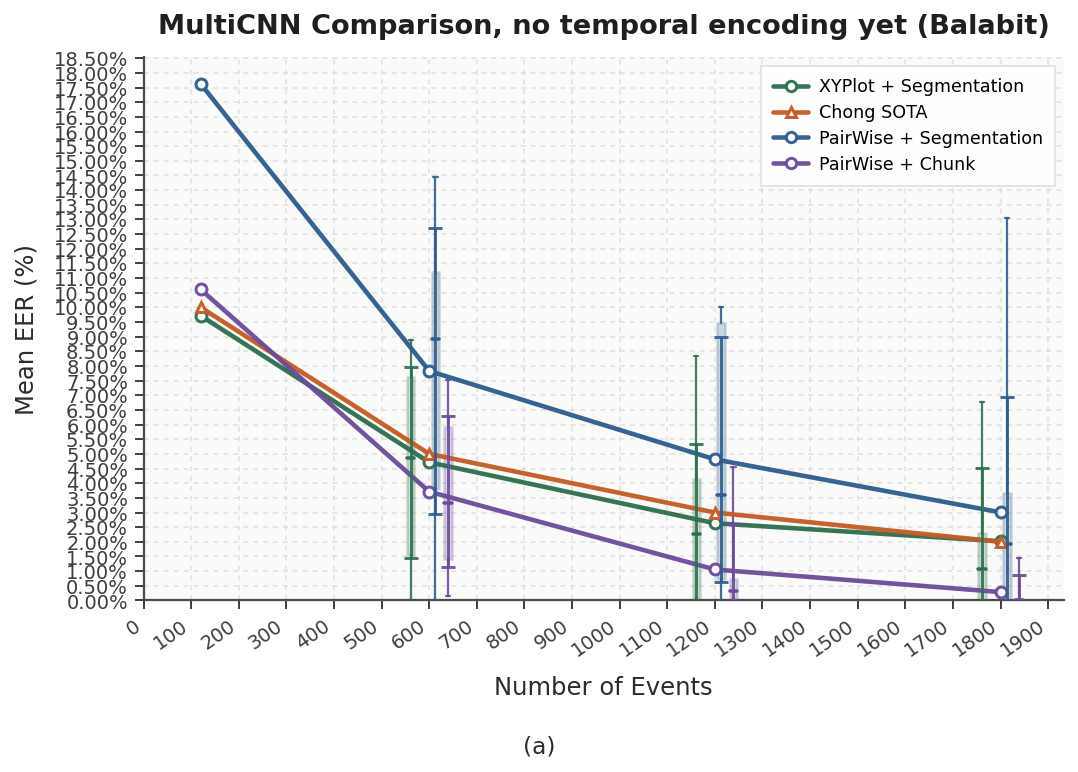

In [2]:
dir_list = [
    "Results/Balabit/CNN/XYPlot_per_user",
    "Results/Balabit/CNN/SOTA",
    "Results/Balabit/CNN/PairWise",
    "Results/Balabit/CNN/PairWise+Chunk",
]

per_user_dir_list = [
    "Results/Balabit/CNN/per-userXYPlot_per_user",
    None,
    "Results/Balabit/CNN/per-userPairWise",
    "Results/Balabit/CNN/per-userPairWise+Chunk",
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=120,
    title="MultiCNN Comparison, no temporal encoding yet (Balabit)",
    legend_names=[
        "XYPlot + Segmentation",
        "Chong SOTA",
        "PairWise + Segmentation",
        "PairWise + Chunk",
    ],
    shift_list=[0, 0, 0, 0],
    marker_list=["o", "^", "o", "o"],
    box_event_positions=(600, 1200, 1800),
    panel_label="(a)",
)

In [3]:
"""
dir_list = [
    "Results/Chong/XYPlot_per_user",
    "Results/Chong/SOTA",
    "Results/Chong/PairWise",
    "Results/Chong/PairWise+Chunk"
]

plot_multiple_result_dirs(
    dir_list,
    max_event=2000,
    seq_length=120,
    title="MultiCNN Comparison, no temporal encoding yet (Balabit)",
    legend_names=["XYPlot + Segmentation", "Chong SOTA", "PairWise + Segmentation", "PairWise + Chunk"],
    shift_list=[0,0,0,0]
)
"""

'\ndir_list = [\n    "Results/Chong/XYPlot_per_user",\n    "Results/Chong/SOTA",\n    "Results/Chong/PairWise",\n    "Results/Chong/PairWise+Chunk"\n]\n\nplot_multiple_result_dirs(\n    dir_list,\n    max_event=2000,\n    seq_length=120,\n    title="MultiCNN Comparison, no temporal encoding yet (Balabit)",\n    legend_names=["XYPlot + Segmentation", "Chong SOTA", "PairWise + Segmentation", "PairWise + Chunk"],\n    shift_list=[0,0,0,0]\n)\n'

In [4]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Balabit/CNN/per-userXYPlot_per_user/MultiCNN.json"
json_cdf = "Results/Balabit/CNN/per-userPairWise+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot + Segmentation",
    label_b="PairWise + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (XYPlot + Segmentation),Mean EER (PairWise + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot + Segmentation vs PairWise + Chunk,1,10,9.71,10.61,0.90,1.000000,False
1,XYPlot + Segmentation vs PairWise + Chunk,2,10,7.10,7.49,0.39,0.845703,False
2,XYPlot + Segmentation vs PairWise + Chunk,3,10,5.94,5.77,0.16,0.431641,False
3,XYPlot + Segmentation vs PairWise + Chunk,4,10,4.96,4.82,0.15,0.492188,False
4,XYPlot + Segmentation vs PairWise + Chunk,5,10,4.71,3.71,1.00,0.193359,False


## Temporal Encoding
## Real Publication Style Plot

## MultiCNN

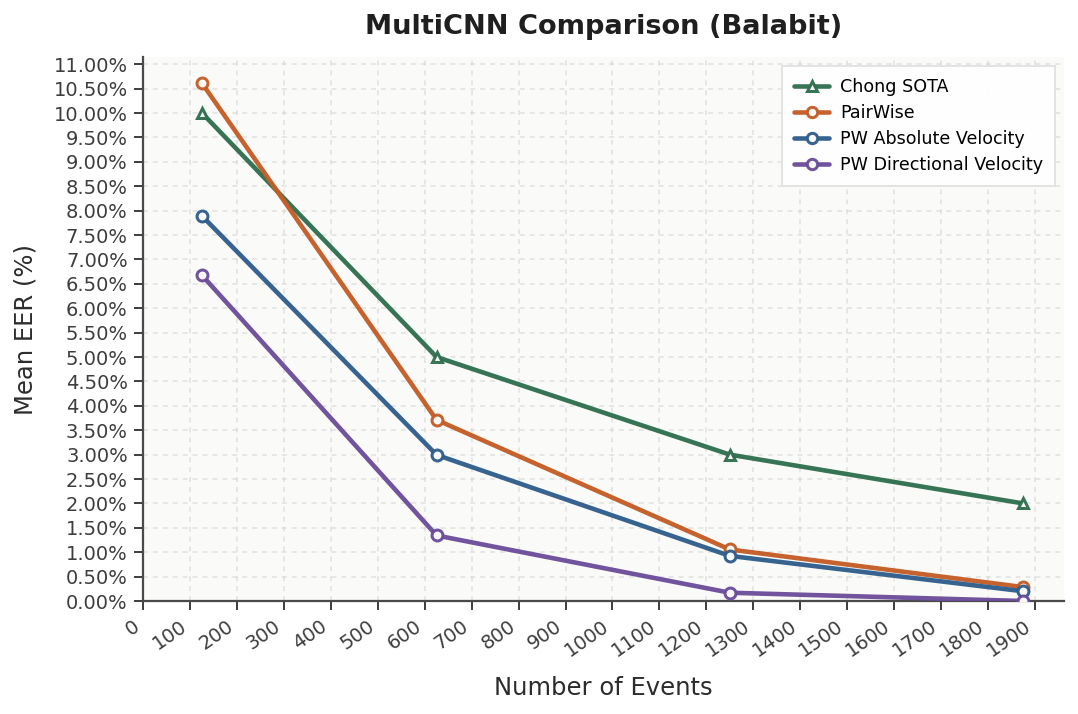

In [5]:
dir_list = [
    "Results/Balabit/CNN/SOTA",
    "Results/Balabit/CNN/PairWise+Chunk",
    "Results/Balabit/CNN/PairWise_velocity+Chunk",
    "Results/Balabit/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    None,
    "Results/Balabit/CNN/per-userPairWise+Chunk",
    "Results/Balabit/CNN/per-userPairWise_velocity+Chunk",
    "Results/Balabit/CNN/per-userPairWise_vxvy+Chunk"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (Balabit)",
    legend_names=[
        "Chong SOTA",
        "PairWise",
         "PW Absolute Velocity",
        "PW Directional Velocity"
    ],
    shift_list=[0, 0, 0, 0],
    marker_list=["^", "o", "o", "o"],
    box_event_positions=(600, 1200, 1800),
    show_boxplots = False,
    show_errorbars=False
)

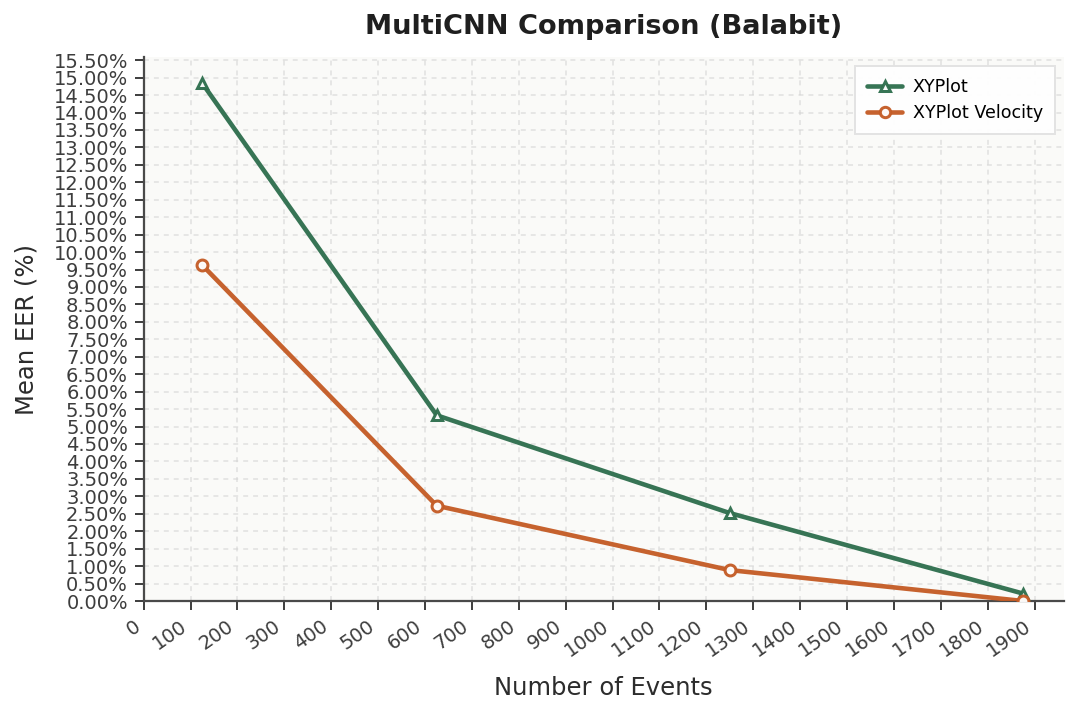

In [6]:
dir_list = [
    "Results/Balabit/CNN/XYPlot_c",
    "Results/Balabit/CNN/XYPlot_velocity_c",
]

per_user_dir_list = [
    "Results/Balabit/CNN/per-userXYPlot_c",
    "Results/Balabit/CNN/per-userXYPlot_velocity_c"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (Balabit)",
    legend_names=[
            "XYPlot",
            "XYPlot Velocity",
      
    ],
    shift_list=[0, 0],
    marker_list=["^", "o"],
    box_event_positions=(600, 1200, 1800),
    show_boxplots = False,
    show_errorbars=False
)

In [8]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Balabit/CNN_new/per-userPairWise+Chunk/MultiCNN.json"
json_cdf = "Results/Balabit/CNN_new/per-userPairWise_vxvy+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="PairWise",
    label_b="PairWise_vxvy + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (PairWise),Mean EER (PairWise_vxvy + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,PairWise vs PairWise_vxvy + Chunk,1,10,10.61,6.67,3.94,0.003906,True
1,PairWise vs PairWise_vxvy + Chunk,2,10,7.49,4.04,3.45,0.003906,True
2,PairWise vs PairWise_vxvy + Chunk,3,10,5.77,2.84,2.94,0.003906,True
3,PairWise vs PairWise_vxvy + Chunk,4,10,4.82,2.12,2.70,0.011719,True
4,PairWise vs PairWise_vxvy + Chunk,5,10,3.71,1.34,2.37,0.001953,True


In [ ]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Balabit/CNN/per-userXYPlot_c/MultiCNN.json"
json_cdf = "Results/Balabit/CNN/per-userPairWise+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="XYPlot c",
    label_b="PairWise + Chunk",
    alpha=0.05
)

df

[Info] numeric index -> user (0->user7, ..., 9->user35):
  0 -> user7
  1 -> user9
  2 -> user12
  3 -> user15
  4 -> user16
  5 -> user20
  6 -> user21
  7 -> user23
  8 -> user29
  9 -> user35
[Info] paired EERs at n=1:
  user7: A[0]=8.78%  B[user7]=2.61%
  user9: A[1]=3.98%  B[user9]=1.06%
  user12: A[2]=15.47%  B[user12]=15.16%
  user15: A[3]=15.51%  B[user15]=11.77%
  user16: A[4]=16.24%  B[user16]=15.13%
  user20: A[5]=20.88%  B[user20]=11.52%
  user21: A[6]=10.69%  B[user21]=7.39%
  user23: A[7]=17.27%  B[user23]=14.40%
  user29: A[8]=17.85%  B[user29]=12.41%
  user35: A[9]=21.74%  B[user35]=14.66%


,Comparison,n,Users,Mean EER (XYPlot c),Mean EER (PairWise + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,XYPlot c vs PairWise + Chunk,1,10,14.84,10.61,4.23,0.001953,True
1,XYPlot c vs PairWise + Chunk,2,10,10.92,7.49,3.43,0.009766,True
2,XYPlot c vs PairWise + Chunk,3,10,7.86,5.77,2.08,0.048828,True
3,XYPlot c vs PairWise + Chunk,4,10,6.54,4.82,1.73,0.160156,False
4,XYPlot c vs PairWise + Chunk,5,10,5.32,3.71,1.61,0.130859,False


In [ ]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Balabit/CNN/per-userPairWise+Chunk/MultiCNN.json"
json_cdf = "Results/Balabit/CNN/per-userPairWise_vxvy+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="PairWise + Chunk",
    label_b="PairWise_vxvy + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (PairWise + Chunk),Mean EER (PairWise_vxvy + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,PairWise + Chunk vs PairWise_vxvy + Chunk,1,10,10.61,6.67,3.94,0.003906,True
1,PairWise + Chunk vs PairWise_vxvy + Chunk,2,10,7.49,4.04,3.45,0.003906,True
2,PairWise + Chunk vs PairWise_vxvy + Chunk,3,10,5.77,2.84,2.94,0.003906,True
3,PairWise + Chunk vs PairWise_vxvy + Chunk,4,10,4.82,2.12,2.70,0.011719,True
4,PairWise + Chunk vs PairWise_vxvy + Chunk,5,10,3.71,1.34,2.37,0.001953,True


In [ ]:
from statistics_things.wilcoxon_curve_compare import wilcoxon_curve_test

json_xy = "Results/Balabit/CNN/per-userPairWise+Chunk/MultiCNN.json"
json_cdf = "Results/Balabit/CNN/per-userPairWise_velocity+Chunk/MultiCNN.json"

n_targets = [i+1 for i in range(5)]

df = wilcoxon_curve_test(
    json_xy,
    json_cdf,
    n_targets,
    label_a="PairWise + Chunk",
    label_b="PairWise_vxvy + Chunk",
    alpha=0.05
)

df

,Comparison,n,Users,Mean EER (PairWise + Chunk),Mean EER (PairWise_vxvy + Chunk),Absolute Diff (%),Wilcoxon p-value,Statistically Significant
0,PairWise + Chunk vs PairWise_vxvy + Chunk,1,10,10.61,7.89,2.72,0.005859,True
1,PairWise + Chunk vs PairWise_vxvy + Chunk,2,10,7.49,4.80,2.69,0.005859,True
2,PairWise + Chunk vs PairWise_vxvy + Chunk,3,10,5.77,3.82,1.95,0.009766,True
3,PairWise + Chunk vs PairWise_vxvy + Chunk,4,10,4.82,3.04,1.77,0.054688,False
4,PairWise + Chunk vs PairWise_vxvy + Chunk,5,10,3.71,2.99,0.72,0.322266,False


## MultiViT

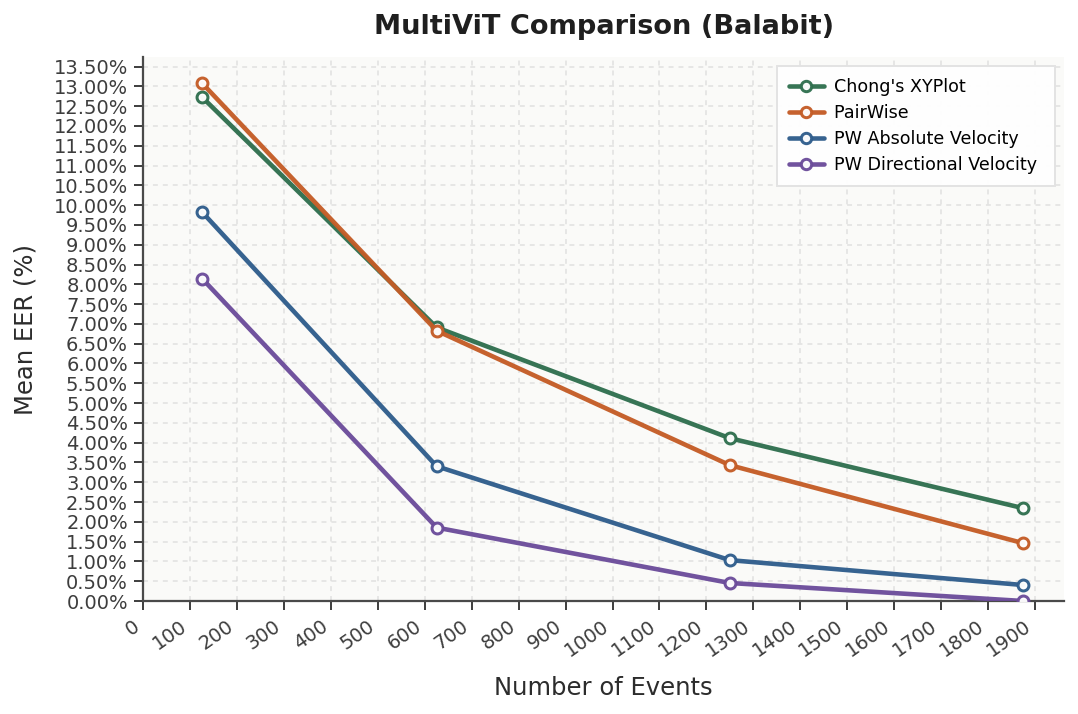

In [ ]:
dir_list = [
    "Results/Balabit/ViT/XYPlot",
    "Results/Balabit/ViT/PairWise+Chunk",
    "Results/Balabit/ViT/PairWise_velocity+Chunk",
    "Results/Balabit/ViT/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/Balabit/ViT/per-userXYPlot",
    "Results/Balabit/ViT/per-userPairWise+Chunk",
    "Results/Balabit/ViT/per-userPairWise_velocity+Chunk",
    "Results/Balabit/ViT/per-userPairWise_vxvy+Chunk"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiViT Comparison (Balabit)",
    legend_names=[
        "Chong's XYPlot",
        "PairWise ",
        "PW Absolute Velocity",
        "PW Directional Velocity "
    ],
    shift_list=[0, 0, 0, 0],
    marker_list=["o", "o", "o", "o"],
    box_event_positions=(600, 1200, 1800),
    drop_max_eer_outlier=True,
    show_boxplots=False,
    show_errorbars=False
)

## ChaoShen

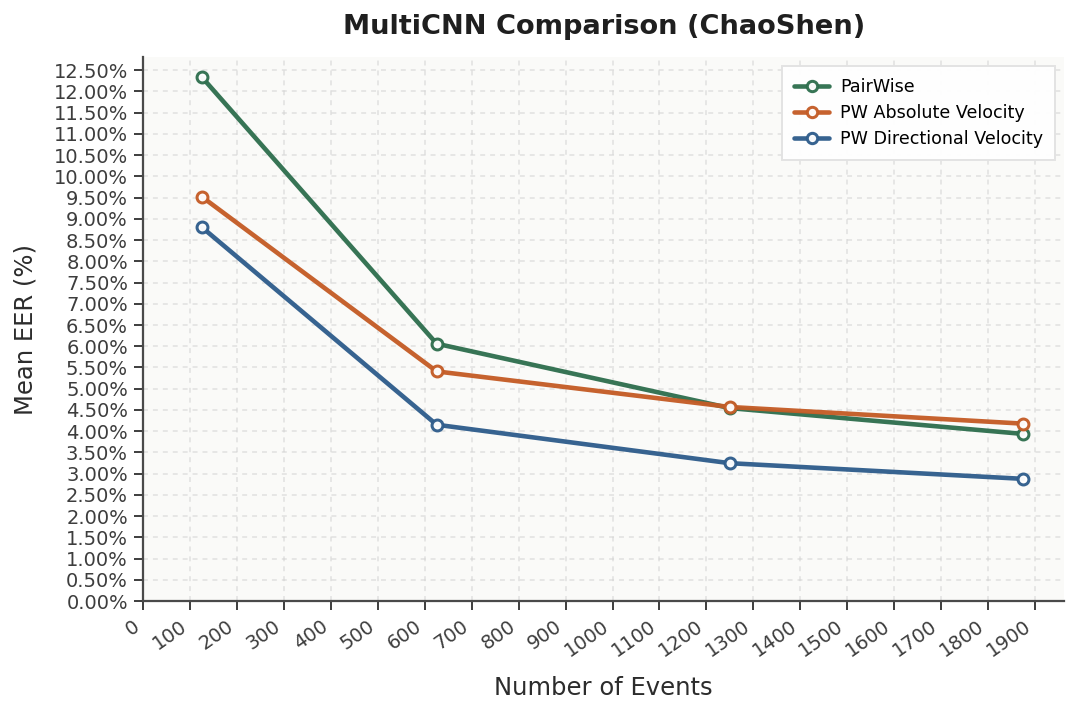

In [ ]:
dir_list = [
    "Results/ChaoShen/CNN/PairWise+Chunk",
    "Results/ChaoShen/CNN/PairWise_velocity+Chunk",
    "Results/ChaoShen/CNN/PairWise_vxvy+Chunk",
]

per_user_dir_list = [
    "Results/ChaoShen/CNN/per-userPairWise+Chunk",
    "Results/ChaoShen/CNN/per-userPairWise_velocity+Chunk",
    "Results/ChaoShen/CNN/per-userPairWise_vxvy+Chunk",
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (ChaoShen)",
    legend_names=[
        
        "PairWise",
        "PW Absolute Velocity",
        "PW Directional Velocity",
        
    ],
    shift_list=[0, 0, 0],
    x_axis_start_event=0,
    marker_list=["o" , "o", "o"],
    box_event_positions=(600, 1200, 1800),
    drop_max_eer_outlier=True,
    show_boxplots=False,
    show_errorbars=False
)

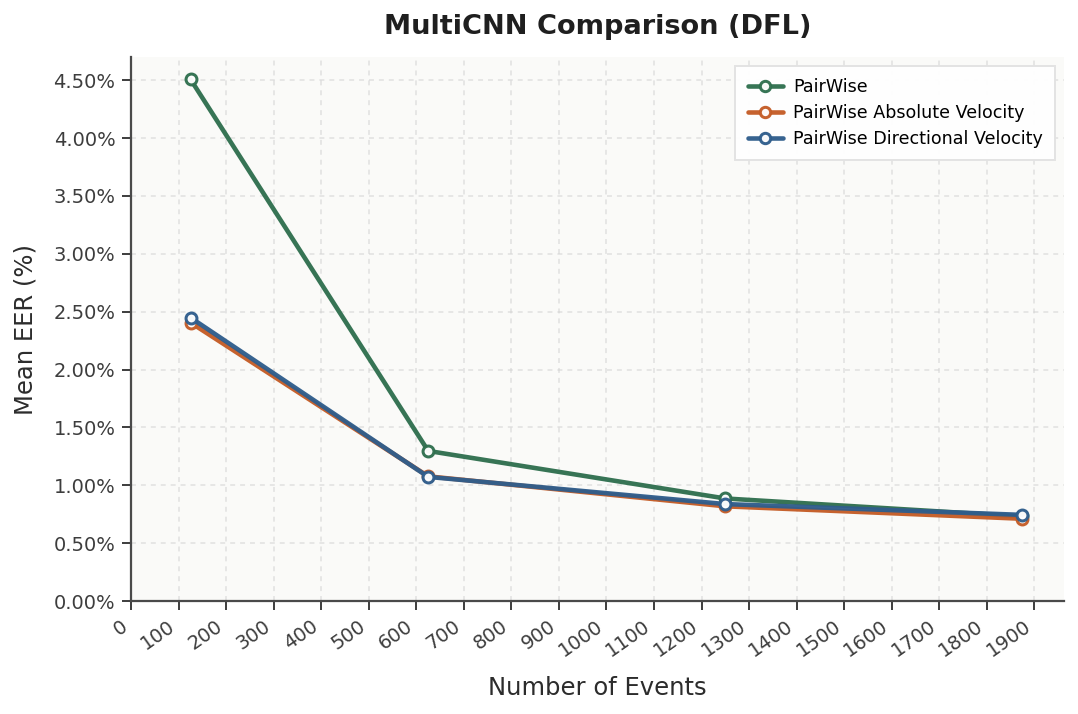

In [ ]:
dir_list = [
    "Results/DFL/CNN/PairWise+Chunk",
    "Results/DFL/CNN/PairWise_velocity+Chunk",
    "Results/DFL/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/DFL/CNN/per-userPairWise+Chunk",
    "Results/DFL/CNN/per-userPairWise_velocity+Chunk",
    "Results/DFL/CNN/per-userPairWise_vxvy+Chunk"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=1875,
    seq_length=125,
    title="MultiCNN Comparison (DFL)",
    legend_names=[
        "PairWise",
        "PairWise Absolute Velocity",
        "PairWise Directional Velocity"
    ],
    shift_list=[0, 0, 0],
    x_axis_start_event=0,
    marker_list=["o", "o", "o"],
    box_event_positions=(600, 1200, 1800),
    drop_max_eer_outlier=True,
    show_boxplots=False,
    show_errorbars=False
)

## TWOS

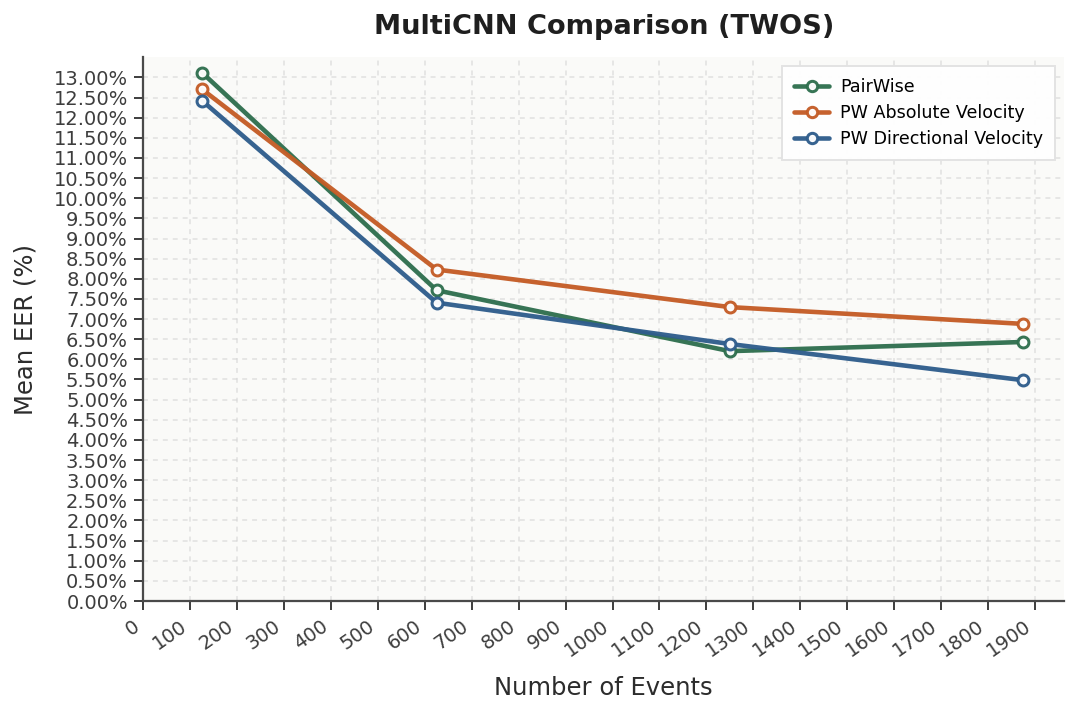

In [ ]:
dir_list = [
    "Results/TWOS/CNN/PairWise+Chunk",
    "Results/TWOS/CNN/PairWise_velocity+Chunk",
    "Results/TWOS/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/TWOS/CNN/per-userPairWise+Chunk",
    "Results/TWOS/CNN/per-userPairWise_velocity+Chunk",
    "Results/TWOS/CNN/per-userPairWise_vxvy+Chunk"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=1875,
    seq_length=125,
    title="MultiCNN Comparison (TWOS)",
    legend_names=[
        "PairWise",
        "PW Absolute Velocity",
        "PW Directional Velocity"
    ],
    shift_list=[0,0,0],
    x_axis_start_event=0,
    marker_list=["o","o", "o"],
    box_event_positions=(600, 1200, 1800),
    drop_max_eer_outlier=True,
    show_boxplots=False,
    show_errorbars=False
)